In [2]:
import pandas as pd

# Load the dataset
file_path = 'Delivery_Logistics_Clean.csv'
df = pd.read_csv(file_path)

# Display basic info and first few rows to understand structure
df_info = df.info()
df_head = df.head()
missing_values = df.isnull().sum()

print("Data Info:")
print(df_info)
print("\nFirst 5 rows:")
print(df_head)
print("\nMissing values:")
print(missing_values)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_partner     25000 non-null  object 
 1   package_type         25000 non-null  object 
 2   vehicle_type         25000 non-null  object 
 3   delivery_mode        25000 non-null  object 
 4   region               25000 non-null  object 
 5   weather_condition    25000 non-null  object 
 6   distance_km          25000 non-null  float64
 7   package_weight_kg    25000 non-null  float64
 8   delivery_time_hours  25000 non-null  int64  
 9   expected_time_hours  25000 non-null  int64  
 10  delayed              25000 non-null  object 
 11  delivery_status      25000 non-null  object 
 12  delivery_rating      25000 non-null  int64  
 13  delivery_cost        25000 non-null  float64
dtypes: float64(3), int64(3), object(8)
memory usage: 2.7+ MB
Data Info:
None

First 5 rows

        distance_km  package_weight_kg  delivery_time_hours  delivery_cost
count  25000.000000       25000.000000         25000.000000   25000.000000
mean     150.390436          25.145898             6.248040     864.944579
std       86.409745          14.368663             3.140935     435.712593
min        3.600000           0.670000             0.000000      95.667400
25%       75.900000          12.680000             4.000000     490.800000
50%      151.000000          25.145000             6.000000     867.535000
75%      224.900000          37.660000             8.000000    1237.910000
max      297.100000          49.520000            19.000000    1632.720600


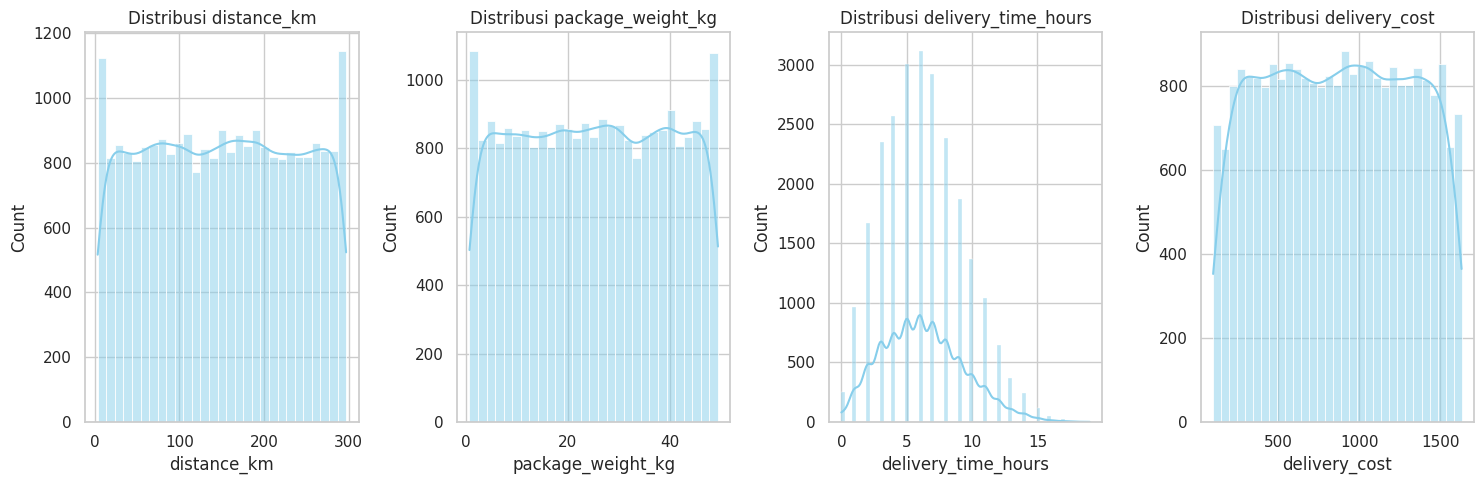

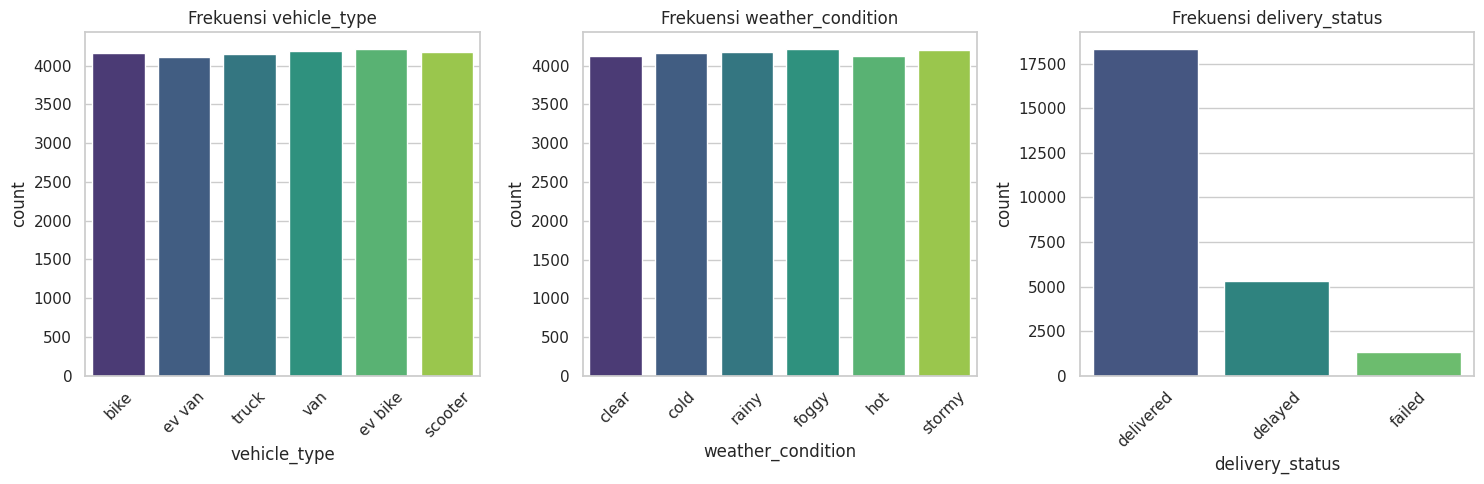

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Analisis Numerik ---
# Statistik deskriptif untuk fitur numerik utama
numerical_cols = ['distance_km', 'package_weight_kg', 'delivery_time_hours', 'delivery_cost']
print(df[numerical_cols].describe())

# Visualisasi Distribusi Numerik (Histogram)
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 4, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

# --- Analisis Kategorikal ---
# Visualisasi Distribusi Kategorikal (Countplot)
categorical_cols = ['vehicle_type', 'weather_condition', 'delivery_status']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i+1)
    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    plt.xticks(rotation=45)
    plt.title(f'Frekuensi {col}')
plt.tight_layout()
plt.show()

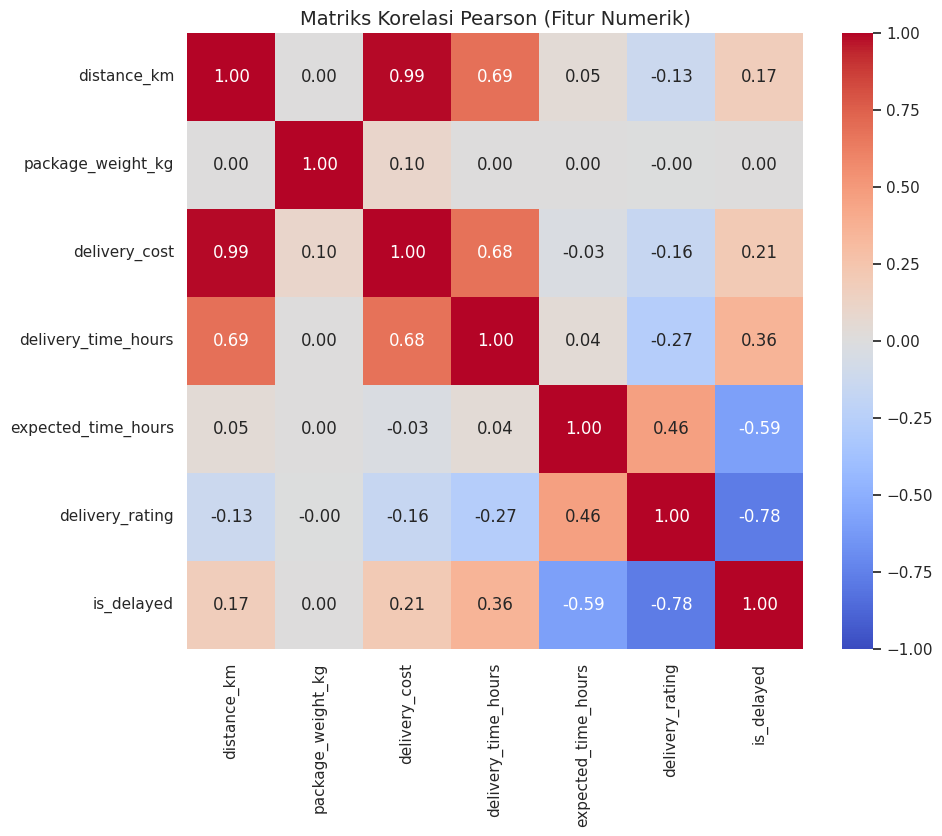

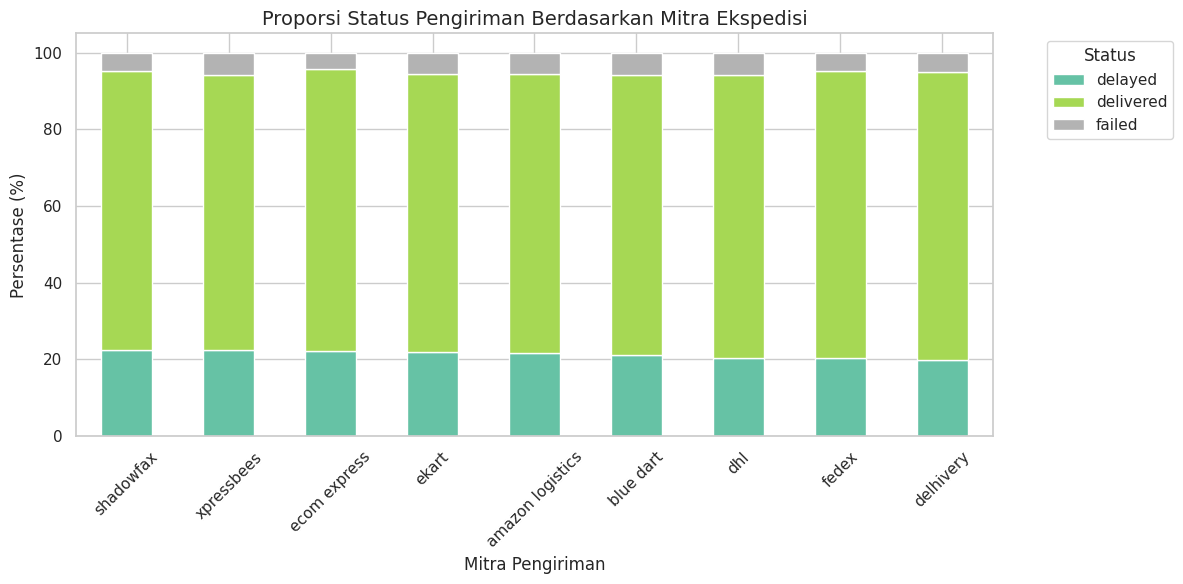

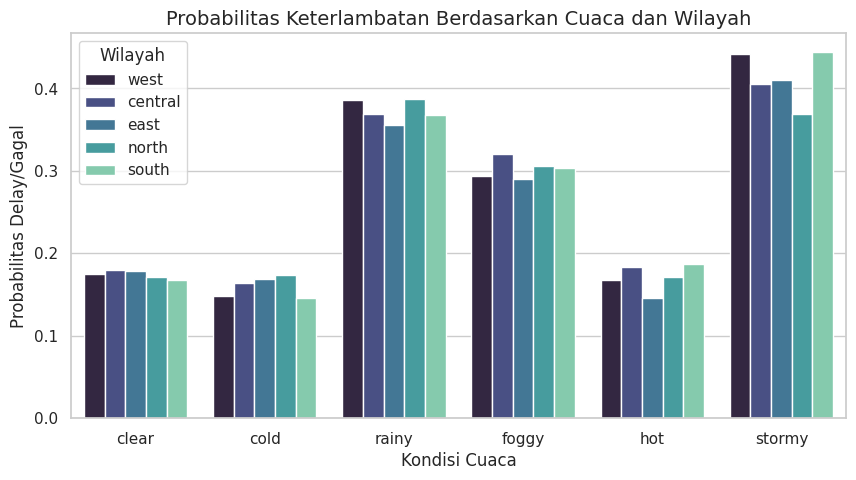

In [1]:
# # 02. Multivariate EDA & Feature Dependency
# ## Objektif Analitik
# Tahap ini bertujuan untuk menganalisis interdependensi antar variabel (multivariate analysis). Analisis difokuskan pada identifikasi hubungan linear antar fitur numerik dan pengaruh fitur kategorikal (seperti wilayah dan mitra) terhadap probabilitas keterlambatan (status `delayed` atau `failed`).

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Memuat dataset
df_clean = pd.read_csv('/content/Delivery_Logistics_Clean.csv')


# ## 1. Analisis Korelasi Fitur Numerik
# Matriks korelasi (Pearson) digunakan untuk mendeteksi multikolinearitas antar variabel prediktor dan melihat korelasi awal dengan indikator keterlambatan.

# %%
# Membuat variabel indikator numerik biner untuk keterlambatan (1=Delayed/Failed, 0=Delivered)
df_clean['is_delayed'] = df_clean['delivery_status'].apply(lambda x: 0 if x == 'delivered' else 1)

# Memilih fitur numerik
numeric_features = ['distance_km', 'package_weight_kg', 'delivery_cost',
                    'delivery_time_hours', 'expected_time_hours', 'delivery_rating', 'is_delayed']

# Menghitung matriks korelasi
corr_matrix = df_clean[numeric_features].corr()

# Visualisasi Heatmap Korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriks Korelasi Pearson (Fitur Numerik)', fontsize=14)
plt.show()


# ## 2. Pengaruh Mitra Pengiriman (Delivery Partner) Terhadap Status
# Mengidentifikasi apakah terdapat mitra pengiriman spesifik yang memiliki rasio kegagalan atau keterlambatan lebih tinggi secara signifikan.

# %%
# Menghitung rasio status pengiriman per mitra
partner_status = pd.crosstab(df_clean['delivery_partner'], df_clean['delivery_status'], normalize='index') * 100

# Mengurutkan berdasarkan persentase delay terbesar
partner_status = partner_status.sort_values(by='delayed', ascending=False)

# Visualisasi Stacked Bar Chart
partner_status.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Proporsi Status Pengiriman Berdasarkan Mitra Ekspedisi', fontsize=14)
plt.xlabel('Mitra Pengiriman')
plt.ylabel('Persentase (%)')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ## 3. Evaluasi Kondisi Cuaca & Wilayah
# Menganalisis dependensi silang antara kondisi cuaca, region geografis, dan probabilitas keterlambatan operasional.


# Visualisasi pengaruh cuaca terhadap probabilitas keterlambatan
plt.figure(figsize=(10, 5))
sns.barplot(data=df_clean, x='weather_condition', y='is_delayed', hue='region', errorbar=None, palette='mako')
plt.title('Probabilitas Keterlambatan Berdasarkan Cuaca dan Wilayah', fontsize=14)
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Probabilitas Delay/Gagal')
plt.legend(title='Wilayah')
plt.show()


# ## Kesimpulan Eksplorasi (Actionable Insights)
# Berdasarkan visualisasi multivariat di atas, hipotesis awal yang dapat dibawa ke tahap *Machine Learning Modeling* adalah:
# 1. Variabel operasional tertentu kemungkinan besar menjadi prediktor kuat.
# 2. Kondisi cuaca berinteraksi secara spesifik dengan topologi wilayah tertentu.
# 3. Fitur `delivery_partner` wajib disertakan dalam *One-Hot Encoding* karena terbukti memiliki varians yang signifikan terhadap status pengiriman.



# Laporan Analisis Insight Logistik Pengiriman

Analisis ini menyajikan temuan kunci dari data operasional pengiriman untuk memahami faktor-faktor yang mendorong keterlambatan dan biaya.

---

### 1. Interpretasi Matriks Korelasi Pearson (Hubungan Antar Variabel)
**Konsep Dasar:** Korelasi Pearson mengukur kekuatan hubungan linear antara dua variabel numerik (skala -1 hingga 1).

*   **Multikolinearitas Sempurna (0.99):** Terdapat korelasi yang hampir sempurna antara `distance_km` dan `delivery_cost`.
    *   *Insight:* Biaya pengiriman ditentukan secara kaku oleh jarak tempuh. Model penetapan harga saat ini sangat linear terhadap jarak.
*   **Indikator Utama Keterlambatan (`is_delayed`):**
    *   **Korelasi Negatif Kuat (-0.78) dengan `delivery_rating`:** Ini menunjukkan bahwa keterlambatan adalah penyebab utama ketidakpuasan pelanggan. Setiap kejadian delay menurunkan rating secara signifikan.
    *   **Korelasi Negatif (-0.59) dengan `expected_time_hours`:** Menariknya, semakin lama estimasi waktu yang diberikan kepada pelanggan, semakin rendah kemungkinan status 'delayed'.
    *   *Rekomendasi:* Memberikan estimasi waktu yang lebih konservatif (buffer time) dapat menurunkan angka keterlambatan teknis.

### 2. Analisis Performa Mitra Ekspedisi
**Konsep Dasar:** Membandingkan efisiensi operasional antar vendor menggunakan proporsi status (Delivered vs Delayed vs Failed).

*   **Ranking Efisiensi:**
    *   **Delhivery** menunjukkan performa terbaik dengan tingkat 'Delivered' tertinggi (~75.2%) dan tingkat keterlambatan terendah.
    *   **Shadowfax** dan **Xpressbees** berada di peringkat bawah dengan tingkat keterlambatan di atas 22%.
*   **Tingkat Kegagalan (Failed):** Mayoritas mitra memiliki tingkat kegagalan sekitar 4-6%.
*   *Insight Strategis:* Perlu dilakukan evaluasi kontrak atau audit operasional terhadap Shadowfax dan Xpressbees untuk mengidentifikasi hambatan spesifik yang mereka hadapi dibandingkan Delhivery.

### 3. Analisis Faktor Risiko: Cuaca dan Wilayah
**Konsep Dasar:** Analisis probabilitas keterlambatan berdasarkan faktor eksternal tak terkendali.

*   **Dampak Cuaca Ekstrem:** Kondisi **Stormy** (Badai) dan **Rainy** (Hujan) meningkatkan probabilitas keterlambatan secara drastis hingga >40% di beberapa wilayah.
*   **Interaksi Wilayah:**
    *   **Wilayah West (Barat) & South (Selatan):** Paling rentan terhadap kondisi *Stormy*, dengan probabilitas keterlambatan mencapai titik tertinggi.
    *   **Wilayah Central (Tengah):** Mengalami lonjakan delay yang signifikan saat cuaca *Foggy* (Berkabut) dibandingkan wilayah lain.
*   *Insight Operasional:* Perusahaan harus mengimplementasikan sistem mitigasi dinamis. Jika cuaca diprediksi *Stormy* di wilayah West/South, SLA (Service Level Agreement) harus otomatis disesuaikan agar ekspektasi pelanggan tetap terjaga.

---

### Kesimpulan Strategis (Actionable Insights)
1.  **Optimasi Estimasi:** Tambahkan buffer waktu pada fitur `expected_time_hours` untuk rute jarak jauh guna memitigasi korelasi positif antara jarak dan waktu tempuh riil.
2.  **Manajemen Vendor:** Alokasikan volume pengiriman lebih banyak ke **Delhivery** untuk rute kritis, dan lakukan pembinaan pada vendor dengan tingkat delay tinggi.
3.  **Alert Cuaca:** Integrasikan API cuaca ke dalam sistem logistik untuk memberikan peringatan dini keterlambatan kepada pelanggan di wilayah terdampak (khususnya South dan West).


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. LOAD DATA
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path)

    # --- FEATURE ENGINEERING ---
    # Membuat rasio efisiensi waktu
    df['efficiency_ratio'] = df['delivery_time_hours'] / df['expected_time_hours']

    # --- ENCODING ---
    le = LabelEncoder()
    # Encoding target
    df['delayed_encoded'] = le.fit_transform(df['delayed'])

    # Encoding fitur kategorikal
    cat_cols = df.select_dtypes(include=['object']).columns.drop('delayed')
    for col in cat_cols:
        df[f'{col}_encoded'] = le.fit_transform(df[col])

    return df

# 2. PREPROCESSING & SCALING
def prepare_features(df):
    # Memilih fitur numerik dan hasil encoding
    features_to_scale = ['distance_km', 'package_weight_kg', 'delivery_time_hours',
                         'expected_time_hours', 'delivery_rating', 'delivery_cost', 'efficiency_ratio']

    # Menambahkan kolom hasil encoding ke daftar fitur
    encoded_cols = [col for col in df.columns if col.endswith('_encoded') and col != 'delayed_encoded']
    X_cols = features_to_scale + encoded_cols

    X = df[X_cols]
    y = df['delayed_encoded']

    # Scaling
    scaler = StandardScaler()
    X.loc[:, features_to_scale] = scaler.fit_transform(X[features_to_scale])

    return X, y

# 3. MODELING & EVALUATION
def run_model_pipeline(X, y):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Inisialisasi Model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Prediksi
    y_pred = model.predict(X_test)

    # Evaluasi
    print("--- EVALUASI MODEL ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return model

# --- EKSEKUSI ---
df_processed = load_and_preprocess_data('Delivery_Logistics_Clean.csv')
X, y = prepare_features(df_processed)
trained_model = run_model_pipeline(X, y)

/tmp/ipykernel_620/2842722426.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.55779416 -1.35250343  1.19456003 ...  0.8761771  -0.0789717
  0.23941123]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[:, features_to_scale] = scaler.fit_transform(X[features_to_scale])
/tmp/ipykernel_620/2842722426.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.67571976 -1.337194    0.38263904 ... -0.67571976  1.44099783
  0.38263904]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[:, features_to_scale] = scaler.fit_transform(X[features_to_scale])
/tmp/ipykernel_620/2842722426.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.57916021  1.16005965  0.29044972 ... -1.44877015

--- EVALUASI MODEL ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3677
           1       1.00      1.00      1.00      1323

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



### 4. Hyperparameter Tuning
Bagian ini bertujuan untuk mencari parameter terbaik bagi model Random Forest menggunakan metode Grid Search untuk menghindari overfitting dan meningkatkan generalisasi model.

In [6]:
from sklearn.model_selection import GridSearchCV

# Mendefinisikan parameter yang akan diuji
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Inisialisasi model
rf = RandomForestClassifier(random_state=42)

# Split data kembali untuk memastikan konsistensi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi Grid Search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Melakukan tuning (Fit)
print("Memulai proses Hyperparameter Tuning...")
grid_search.fit(X_train, y_train)

# Menampilkan parameter terbaik
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-validation Score: {grid_search.best_score_:.4f}")

Memulai proses Hyperparameter Tuning...
Fitting 3 folds for each of 54 candidates, totalling 162 fits

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-validation Score: 1.0000


--- EVALUASI MODEL SETELAH TUNING ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3677
           1       1.00      1.00      1.00      1323

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



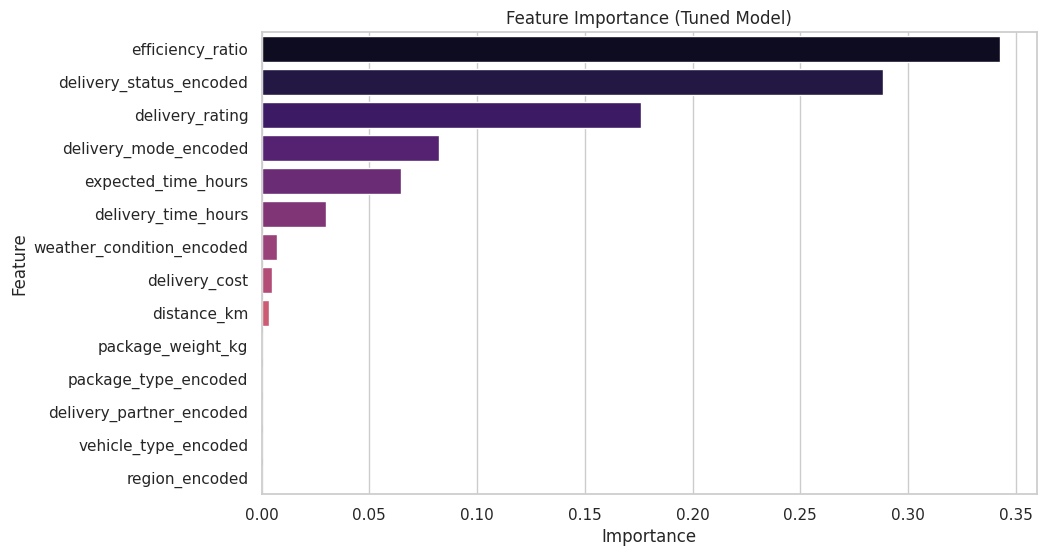

In [7]:
# Evaluasi Model Terbaik pada Test Set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("--- EVALUASI MODEL SETELAH TUNING ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

# Menampilkan Feature Importance untuk melihat pengaruh insight dari EDA
importances = best_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma', hue='Feature', legend=False)
plt.title('Feature Importance (Tuned Model)')
plt.show()